# Assignment 3
##### EECE 5644- Introduction to Machine Learning

This notebook processes car data taken from WheelsBazaar and predicts the prices of cars based on their attributes.

1. Load and inspect the data read car details v4.csv (2058 rows), confirm the target is target (MonthlyCharges,
continuous), and verify the service columns are clean 0/1 indicators with no missing values.

In [74]:
import pandas as pd
import sklearn as sk
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Read the raw dataframe
df = pd.read_csv('car details v4.csv')

# Display head of dataset
print(f"Dataset columns: {list(df.columns)}")
TARGET = "Price"            # Set the target field of the dataset

# Verify the datatype of the target
print("Target type: ", df[TARGET].dtype)
print(f"Maximum target value: ₹{df[TARGET].max()}")
print(f"Maximum target value: ₹{df[TARGET].min()}")

# Drop bad rows
df = df.dropna(axis=0)

# Store a list of features that are deemed important
inputs = df.drop(["Price"], axis="columns")
inputs = inputs.drop(["Seller Type", "Max Power", "Max Torque", "Drivetrain", "Model", "Location"], axis="columns")

print(f"Used columns: {list(inputs.columns)}")

target = df["Price"]

Dataset columns: ['Make', 'Model', 'Price', 'Year', 'Kilometer', 'Fuel Type', 'Transmission', 'Location', 'Color', 'Owner', 'Seller Type', 'Engine', 'Max Power', 'Max Torque', 'Drivetrain', 'Length', 'Width', 'Height', 'Seating Capacity', 'Fuel Tank Capacity']
Target type:  int64
Maximum target value: ₹35000000
Maximum target value: ₹49000
Used columns: ['Make', 'Year', 'Kilometer', 'Fuel Type', 'Transmission', 'Color', 'Owner', 'Engine', 'Length', 'Width', 'Height', 'Seating Capacity', 'Fuel Tank Capacity']


2. Clean the dataset so linear regression can be performed

In [75]:
# Create new df to store cleaned values
inputs_cleaned = inputs

# Fix the engine attributes (remove the trailing 'cc')
inputs_cleaned['Engine'] = inputs_cleaned['Engine'].str.replace(' cc', '')
print(inputs_cleaned.head())

# Do one-hot encoding on categorical rows
categorical_cols = ["Make", "Fuel Type", "Transmission", "Color", "Owner"]
inputs_cleaned = pd.get_dummies(inputs_cleaned, columns=categorical_cols, drop_first=True)


            Make  Year  Kilometer Fuel Type Transmission   Color   Owner  \
0          Honda  2017      87150    Petrol       Manual    Grey   First   
1  Maruti Suzuki  2014      75000    Diesel       Manual   White  Second   
2        Hyundai  2011      67000    Petrol       Manual  Maroon   First   
3         Toyota  2019      37500    Petrol       Manual     Red   First   
4         Toyota  2018      69000    Diesel       Manual    Grey   First   

  Engine  Length   Width  Height  Seating Capacity  Fuel Tank Capacity  
0   1198  3990.0  1680.0  1505.0               5.0                35.0  
1   1248  3995.0  1695.0  1555.0               5.0                42.0  
2   1197  3585.0  1595.0  1550.0               5.0                35.0  
3   1197  3995.0  1745.0  1510.0               5.0                37.0  
4   2393  4735.0  1830.0  1795.0               7.0                55.0  


3. Split the dataset and perform linear regression

In [78]:
from sklearn.metrics import r2_score

target_log = np.log1p(target)  # log1p handles any zero values safely
X_train, X_test, y_train, y_test = train_test_split(inputs_cleaned, target_log, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# Convert log predictions and actuals back to real price
r2_train = r2_score(np.expm1(y_train), np.expm1(model.predict(X_train)))
r2_test = r2_score(np.expm1(y_test), np.expm1(model.predict(X_test)))

print(f"Train R²: {r2_train:.3f}")
print(f"Test R²: {r2_test:.3f}")


Train R²: 0.859
Test R²: 0.672


4. Display the effect of each of the parameters: numerical

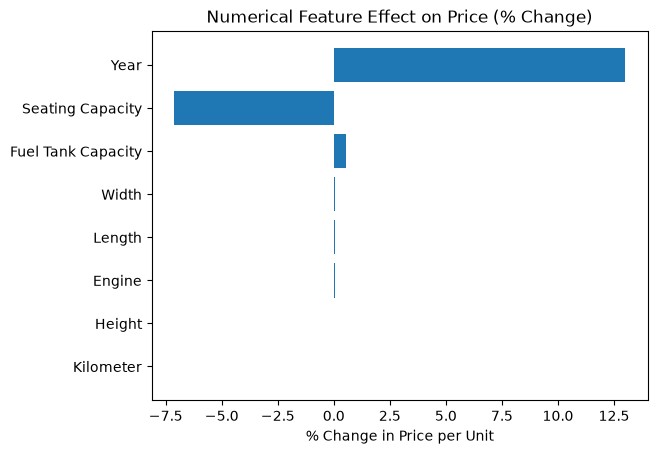

              Feature   Coefficient  % Change in Price
0                Year  1.221829e-01          12.996080
6    Seating Capacity -7.384397e-02          -7.118339
7  Fuel Tank Capacity  5.345513e-03           0.535983
4               Width  5.795748e-04           0.057974
3              Length  4.817782e-04           0.048189
2              Engine  3.923209e-04           0.039240
5              Height  1.663381e-04           0.016635
1           Kilometer -4.051599e-07          -0.000041


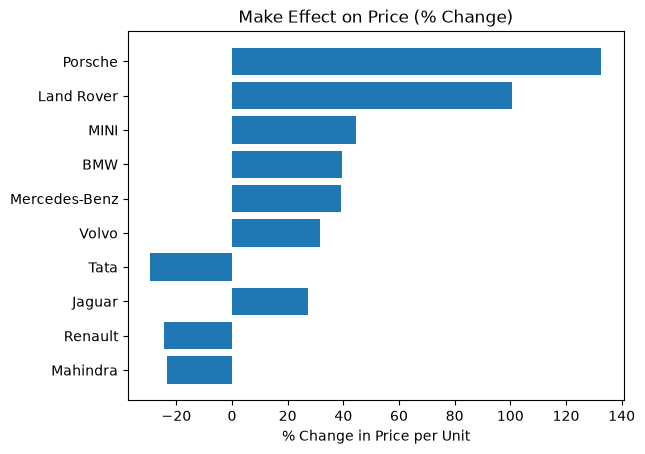

          Feature  Coefficient  % Change in Price
30        Porsche     0.844603         132.705319
20     Land Rover     0.696145         100.600467
23           MINI     0.368257          44.521344
8             BMW     0.332105          39.389931
27  Mercedes-Benz     0.330263          39.133332
38          Volvo     0.275135          31.670815
35           Tata    -0.346587         -29.290267
17         Jaguar     0.241896          27.366116
31        Renault    -0.280165         -24.434086
24       Mahindra    -0.264464         -23.238233


In [95]:
import matplotlib.pyplot as plt
import numpy as np

coefficients_raw = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

# Convert log-scale coefficients to % change in price
coefficients_raw['% Change in Price'] = (np.exp(coefficients_raw['Coefficient']) - 1) * 100

# Sort values into ascending percentages
coefficients_raw = coefficients_raw.sort_values('% Change in Price', key=abs, ascending=False)

# Remove raw features
coeff_numerical = coefficients_raw[~coefficients_raw['Feature'].str.contains('_')]

top_n = coeff_numerical.head(10)
plt.barh(top_n['Feature'], top_n['% Change in Price'])
plt.xlabel('% Change in Price per Unit')
plt.title('Numerical Feature Effect on Price (% Change)')
plt.gca().invert_yaxis()
plt.show()
print(top_n)

coeff_make = coefficients_raw[coefficients_raw['Feature'].str.contains('Make')]
coeff_make['Feature'] = coeff_make['Feature'].str.replace("Make_", "")
top_n = coeff_make.head(10)
plt.barh(top_n['Feature'], top_n['% Change in Price'])
plt.xlabel('% Change in Price per Unit')
plt.title('Make Effect on Price (% Change)')
plt.gca().invert_yaxis()
plt.show()
print(top_n)
